<a href="https://colab.research.google.com/github/Misha2636/Junior-Data-Scientist-ML-Intern-Python-Machine-Learning-Data-Analysis-/blob/main/Project2-Customer_Support_Ticket_Classifier_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎧 Customer Support Ticket Classifier (NLP)

**Author:** Amisha (“Misha”)  
**Goal:** Build a natural language processing model to automatically classify customer support tickets by issue type.

## Project Objectives
- Clean and preprocess support ticket text
- Convert text into numerical features using TF-IDF
- Train and evaluate classification models
- Interpret results using precision and recall

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

sns.set(style="whitegrid")

In [4]:
import os
os.listdir("/content")

['.config', 'sample_data']

In [5]:
df = pd.read_csv("/customer_support_tickets.csv")
df.head()

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [6]:
df = pd.read_csv("/enhanced_customer_support_data.csv")
df.head()


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [7]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Ticket_ID              20000 non-null  object
 1   Customer_Name          20000 non-null  object
 2   Customer_Email         20000 non-null  object
 3   Ticket_Subject         20000 non-null  object
 4   Ticket_Description     20000 non-null  object
 5   Issue_Category         20000 non-null  object
 6   Priority_Level         20000 non-null  object
 7   Ticket_Channel         20000 non-null  object
 8   Submission_Date        20000 non-null  object
 9   Resolution_Time_Hours  20000 non-null  int64 
 10  Assigned_Agent         20000 non-null  object
 11  Satisfaction_Score     20000 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 1.8+ MB


,0
Ticket_ID,0
Customer_Name,0
Customer_Email,0
Ticket_Subject,0
Ticket_Description,0
Issue_Category,0
Priority_Level,0
Ticket_Channel,0
Submission_Date,0
Resolution_Time_Hours,0


### Dataset Overview
- The dataset contains customer-submitted support ticket text and corresponding issue categories.
- Text data will require preprocessing before model training.

In [8]:
# Define column names (run this cell FIRST)
TEXT_COL = "Ticket_Description"
SUBJECT_COL = "Ticket_Subject"
LABEL_COL = "Issue_Category"

In [9]:
df[TEXT_COL] = df[TEXT_COL].fillna("")

df["clean_text"] = df[TEXT_COL].str.lower()
df["clean_text"] = df["clean_text"].str.replace(r"[^a-zA-Z\s]", "", regex=True)
df["clean_text"] = df["clean_text"].str.replace(r"\s+", " ", regex=True).str.strip()

df[[TEXT_COL, "clean_text"]].head()

,Ticket_Description,clean_text
0,"Hi Support, Where is your headquarters located...",hi support where is your headquarters located ...
1,"Hi Support, The application crashes every time...",hi support the application crashes every time ...
2,"Hi Support, How do I upgrade to the Enterprise...",hi support how do i upgrade to the enterprise ...
3,"Hi Support, The dashboard is not loading any d...",hi support the dashboard is not loading any da...
4,"Hi Support, I have been trying to update my pa...",hi support i have been trying to update my pay...


In [10]:
print("Missing labels:", df[LABEL_COL].isna().sum())
print("Unique categories:", df[LABEL_COL].nunique())
df[LABEL_COL].value_counts()

Missing labels: 0
Unique categories: 5


,count
Issue_Category,
Technical,5918
Billing,5036
Account,4081
General Inquiry,3925
Fraud,1040


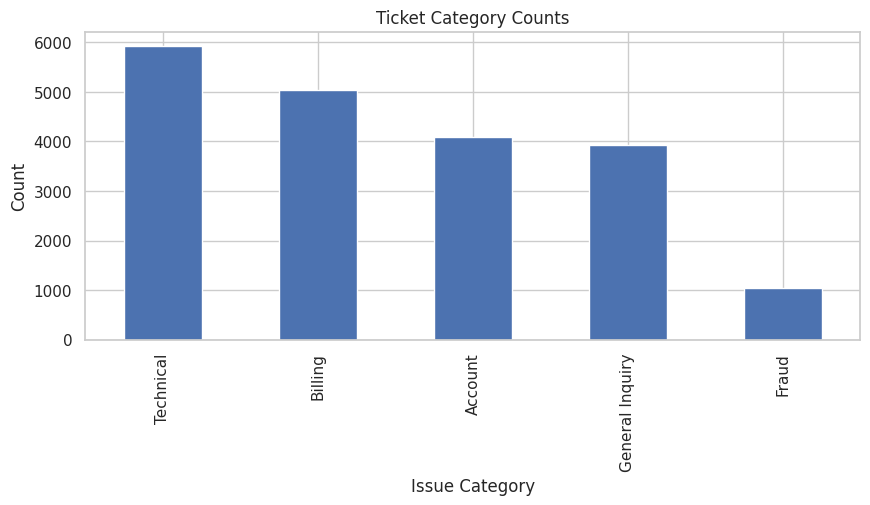

In [11]:
plt.figure(figsize=(10,4))
df[LABEL_COL].value_counts().plot(kind="bar")
plt.title("Ticket Category Counts")
plt.xlabel("Issue Category")
plt.ylabel("Count")
plt.show()

In [12]:
df.columns.tolist()

['Ticket_ID',
 'Customer_Name',
 'Customer_Email',
 'Ticket_Subject',
 'Ticket_Description',
 'Issue_Category',
 'Priority_Level',
 'Ticket_Channel',
 'Submission_Date',
 'Resolution_Time_Hours',
 'Assigned_Agent',
 'Satisfaction_Score',
 'clean_text']

In [13]:
# Define schema (safe to re-run)
TEXT_COL = "Ticket_Description"
SUBJECT_COL = "Ticket_Subject"
LABEL_COL = "Issue_Category"

In [14]:
# Fill missing values
df[TEXT_COL] = df[TEXT_COL].fillna("")
df[SUBJECT_COL] = df[SUBJECT_COL].fillna("")

In [15]:
# Create combined text column
df["combined_text"] = (df[SUBJECT_COL] + " " + df[TEXT_COL]).str.lower()

# Clean text (regex-safe)
df["combined_text"] = df["combined_text"].str.replace(r"[^a-zA-Z\s]", "", regex=True)
df["combined_text"] = df["combined_text"].str.replace(r"\s+", " ", regex=True).str.strip()

# Verify creation
df[["combined_text", LABEL_COL]].head()

,combined_text,Issue_Category
0,hours of operation individual hi support where...,General Inquiry
1,data not syncing card hi support the applicati...,Technical
2,fa issues question hi support how do i upgrade...,Account
3,login failed let hi support the dashboard is n...,Technical
4,refund status attention hi support i have been...,Billing


In [16]:
X = df["combined_text"]
y = df[LABEL_COL]

## Model Interpretation

- This model uses TF-IDF features to convert ticket text into numeric signals that ML models can learn from.
- Linear SVM typically performs strongly for text classification problems, and the classification report shows how well the model predicts each Issue_Category.
- Precision reflects how often predicted categories are correct, while recall reflects how well the model finds tickets that truly belong to each category.
- This kind of ticket triage model can support faster routing and more consistent handling of customer support workflows.


## Final Takeaways
This project demonstrates how natural language processing can be applied to real-world customer support scenarios. Automating ticket classification can improve response time and operational efficiency.